<a href="https://colab.research.google.com/github/Loading-my-brain/GEOG761_Remote_Sensing/blob/main/Lab1_Tasks_only_hnis651_Hinami_Nishi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set Up

This lab has drawn upon the following sources, tutorials and repos:

*   https://geemap.org/
*   https://developers.google.com/earth-engine

In [1]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='earthengine-ml-testing-502922')

import geemap

# **The Tasks**





## **Task 1**

(1) Find and add the basemap 'OpenTopoMap' to the display window AND change the code so that the map opens and zooms to the city of Auckland.
Provide a link to your code in a notebook and the output as a figure in the answer proforma. (2 pts)

In [2]:

# Task1 - for assessment
AKL_city_Map = geemap.Map(center=(-36.84777289548802, 174.76042775520804), #I got these coordinates from Google Maps
                 zoom=11)
AKL_city_Map.add_basemap("OpenTopoMap")
AKL_city_Map

Map(center=[-36.84777289548802, 174.76042775520804], controls=(WidgetControl(options=['position', 'transparent…

In [3]:
# Alternatively for Task 1
AKL_city_Map2 = geemap.Map(center=(-36.84777289548802, 174.76042775520804), zoom=11, basemap="OpenTopoMap")
AKL_city_Map2

Map(center=[-36.84777289548802, 174.76042775520804], controls=(WidgetControl(options=['position', 'transparent…



---

## **Task 2**

In [4]:
Map = geemap.Map(center=(-41, 172), zoom=4)
dem = ee.Image("USGS/SRTMGL1_003")
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")#The European Space Agency’s global land cover map for 2009.

landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")#A composite of Landsat 7 Top-of-Atmosphere (TOA) imagery captured across a 5-year period (1999–2003).
states = ee.FeatureCollection("TIGER/2018/States")#A vector dataset containing United States state boundary polygons provided by the US Census Bureau.

# Set visualization parameters.
vis_params = {
    "min": 0,
    "max": 4000,
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"],
}


# Some Notes(Hinami):
# Raw satellite or elevation data values rarely correspond directly to visible
#screen pixels (0–255 grayscale or RGB). Visualization parameters map scientific data values to colors:
# - 0 represents sea level.
# - 4000 represents high mountain peaks (e.g., Aoraki / Mount Cook is ~3,724 m).
# - Values at or below 0 get the first color in the palette; values at or above 4000 get the last color. Anything in between gets linearly stretched.


# Add a variety of different Earth Engine layers to the Map object
Map.addLayer(dem, vis_params, "SRTM DEM", True, 0.5)
Map.addLayer(landcover, {}, "Land cover")
Map.addLayer(
    landsat7, {"bands": ["B4", "B3", "B2"], "min": 20, "max": 200}, "Landsat 7"
)
Map.addLayer(states, {}, "US States")

# dem: The raster image object to draw.
# vis_params: Applies the elevation color palette defined above.
# "SRTM DEM": The display title shown in the interactive map layer manager.
# True: Sets whether the layer is visible by default when loaded (True = checked).
# 0.5: Sets layer opacity to 50%, allowing underlying basemaps to show through.

In [5]:

# ## **Revision Hinami**

# # SRTM DEM
#  The Shuttle Radar Topography Mission Digital Elevation Model is a near-global relief map of Earth's land surface created from radar data captured by the Space Shuttle Endeavour in February 2000. It provides high-resolution elevation data used widely in mapping, science, and engineering

# ## Pros

# * Global Consistency: Uniform data collection ensures standard quality worldwide.
# * Easy Access: Free to download globally via platforms like EarthExplorer.
# * Vegetation Penetration: C-band radar partially penetrates thick forest canopies.
# * Fewer Voids: Newer processed versions have corrected missing data gaps.

# ## Cons

# * Outdated Data: Captures Earth’s surface exactly as it was in February 2000.
# * Canopy Topography: Measures forest tops, not true bare-earth ground elevation.
# * Urban Distortion: Tall buildings scatter radar waves, causing height errors.
# * Polar Gaps: Misses areas completely above 60°N and below 56°S.

# ## Primary Usages

# * Terrain Visualization: Creating 3D maps and flight simulations.
# * Disaster Management: Modeling flood zones, landslides, and volcanic hazards.
# * Infrastructure Planning: Route planning for pipelines, roads, and cell towers.
# * Environmental Studies: Tracking soil erosion and defining ecological zones.

# [Documentation](https://lpdaac.usgs.gov/documents/179/SRTM_User_Guide_V3.pdf)


---

### **Hinami's Answer**:

The dataset *LANDSAT/LE7_TOA_5YEAR/1999_2003* is a composite of Landsat 7 Top-of-Atmosphere imagery captured across a five-year period (1999–2003).

Band Combination Used:

* B4 (30 m, 0.77–0.90 μm): Near-Infrared (NIR)
* B3 (30 m, 0.63–0.69 μm): Red
* B2 (30 m, 0.52–0.60 μm): Green

Combining bands 4, 3, and 2 creates a standard false-color infrared composite image where vegetation appears red, land-water interfaces are sharp, and water boundaries are distinct. Because healthy green vegetation absorbs visible light for photosynthesis but strongly reflects NIR radiation, vegetated landscapes yield very high reflectance in Band 4. When these high-intensity NIR values are routed into the red display channel of a screen, those pixels emit strong red light, causing vegetated areas to display as distinctly red or red-tinged.




---


## **Task 3**

(3) Correct the display of the Landsat 7 image so that it displays in '[True Colour](https://weather.ndc.nasa.gov/sport/training/quickGuides/rgb/QuickGuide_TrueColorRGB_NASA_SPoRT.pdf)'. Provide a notebook example of your code and the corrected output over the whole of New Zealand. (10 pts)

In [6]:
# [ee.ImageCollection("LANDSAT/LE7_TOA_5YEAR") document ](https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LE7_TOA_5YEAR)

# Add Earth Engine datasets to our map by first creating variables to hold the calls to the EE api
NZ_Map = geemap.Map(center=(-41, 172), zoom=5)
dem = ee.Image("USGS/SRTMGL1_003")#The Shuttle Radar Topography Mission (SRTM) global digital elevation dataset at 30-meter resolution.
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")#The European Space Agency’s global land cover map for 2009.
#Selects only the specific band named "landcover" from the multi-band raster image.


landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")#A composite of Landsat 7 Top-of-Atmosphere (TOA) imagery captured across a 5-year period (1999–2003).
#states = ee.FeatureCollection("TIGER/2018/States")#A vector dataset containing United States state boundary polygons provided by the US Census Bureau.

# Set visualization parameters.
vis_params = {
    "min": 0,
    "max": 4000, #<- if your satellite image is all white or all black, these vis params are the first thing to check and change
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"], #<-these are HTML colour codes
}

# Hinami's Notes:
# Raw satellite or elevation data values rarely correspond directly to visible
#screen pixels (0–255 grayscale or RGB). Visualization parameters map scientific data values to colors:
# - 0 represents sea level.
# - 4000 represents high mountain peaks (e.g., Aoraki / Mount Cook is ~3,724 m).
# - Values at or below 0 get the first color in the palette values at ;or above 4000 get the last color. Anything in between gets linearly stretched.


NZ_Map.addLayer(dem, vis_params, "SRTM DEM", True, 0.5)
NZ_Map.addLayer(landcover, {}, "Land cover")
NZ_Map.addLayer(
    landsat7,
     {"bands": ["B3", "B2", "B1"],
      "min": 0,
      "max": 90},
    "Landsat 7 True Colour"
)
#NZ_Map.addLayer(states, {}, "US States")
NZ_Map


Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

Hinami's Notes/reflections(not for assessment):

* Visual Parametrs for the bands. In the documentation for the image collectio(landsat 7),  it says "Reflectance ([0,1]) in bands B1, B2, B3, B4, B5, and B7 is scaled to **8 bits ([0,255])** and temperature in band B6_VCID_2 is converted to units of Kelvin-100". Scaled to 8 bits means 2^8 = 256, which means that 256 total unique combinations. So the ranges should be from 0 to 256. This is how I initally chose these 2 min and max values. But! They're hard to seeee! When I reduced the max value lower to 80, it applies a contrast stretch. Since most land surface reflectance values fall well below 255 (with values near 255 usually reserved for bright clouds or snow), setting max: 80 brightens the ground features and spreads their values across the display range, making the image much clearer and easier to inspect

---



## **Task 4**

(4) Why are we using the surface reflectance (SR) here rather than the top of atmosphere (ToA)? (2 pt)




### **Hinami's Answer**

TOA:
[Documentation/Source of info Link about TOA](https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_TOA)


We use Surface Reflectance (SR) instead of Top-of-Atmosphere(TOA) reflectance because:

1. **Atmospheric Correction:** TOA data measures radiation at the satellite sensor and includes noise caused by atmospheric scattering and absorption (from gases, water vapor, and aerosols). SR data undergoes atmospheric correction, removing these atmospheric distortions to measure the actual light reflected directly from the Earth's surface.

2. **Accurate Spectral Classification:** Our goal in this lab is land cover classification. SR provides true physical land surface properties, alloqing spectral signatures consistent across time, space, and different lighting conditions. Using SR ensures our classification relies on actual differences in surface materials (like soil, water, and vegetation) rather than variations in atmospheric conditions.

------


## **Task 5**

In [7]:
# Add in a library for plotting the data we extract
import matplotlib.pyplot as plt

# Define a point and a small rectangular region around it
point = ee.Geometry.Point([174.7633, -36.8485])  # Auckland, NZ
region = point.buffer(150).bounds()  # ~300 m box

# Load a Landsat 7 Collection 2 Level 2 SR image (surface reflectance)
image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2002-01-01', '2002-12-31') \
    .sort('CLOUD_COVER') \
    .first()


# Select surface reflectance bands and apply scale factor
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}

scale_factor = 2.75e-5  # From USGS documentation for Landsat C2 L2

(5) What is a 'scale factor' as has been used in the prior code cell, and why are they used in satellite data storage-to-processing workflows such as this? (2 pts)


### Hinami's Answer:
A value scaling factor is a multiplier used to convert stored raw digital numbers in satellite imagery into meaningful physical units such as surface reflectance (fractions between 0.0 and 1.0)

Physical units = (DN * Scale Factor) + Offset.

The scale factor value were found in the documentation for (LANDSAT/LE07/C02/T1_L2) and for the surface reflectance bands scale facotrs used in for this secion of code is 2.75e-05(with an offset of -0.2).

Scale factors are used in storage and processing workflows becuase:

1. **Data Compression & Storage:** Storing pixel data as 16-bit integers rather than floating-point decimals reduces file sizes and memory usage across massive cloud satellite archives.


2. **Computational Speed:** Processing integer values in Earth Engine workflows is much faster than performing operations on decimal arrays.

---

#### Consequences of NOT applying the scale factor(not for assessment; these are for meee):

* **Invalid Spectral Indices:** Formulas like NDVI ($\frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$) break because raw integer inputs and unapplied offsets corrupt the mathematical ratios, yielding values outside the standard $[-1.0, 1.0]$ range.
* **Nonsensical Physical Values:** Reflectance displays as arbitrary values in the thousands (e.g., $15,000$) instead of actual percentages ($0.15$ or $15\%$).
* **Loss of Inter-Sensor Comparability:** You cannot compare images across time, scenes, or sensors (e.g., Landsat 7 vs. Landsat 8) because raw DNs are uncalibrated and sensor-specific.
* **Classification Errors:** Machine learning models will be distorted because unscaled bands with higher arbitrary ranges will improperly dominate classification algorithms.

---


## **Task 6**


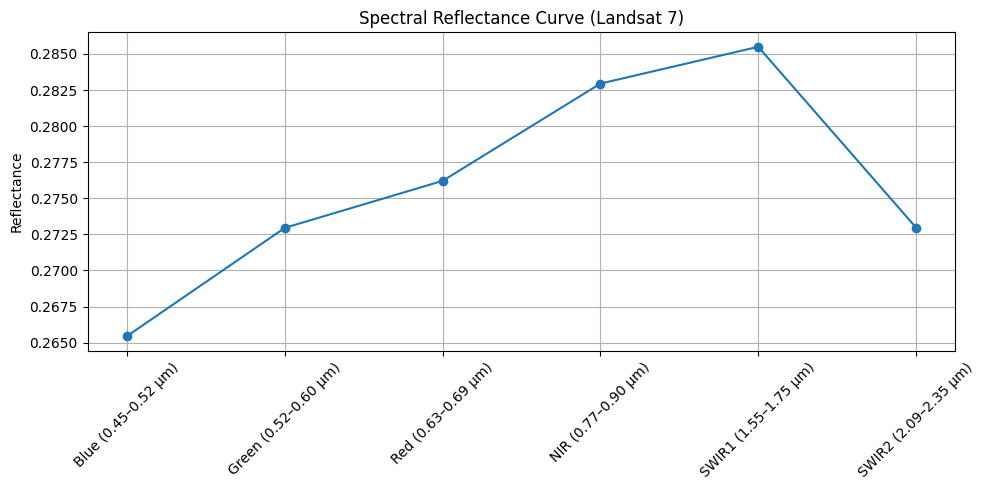

In [8]:
# Reduce region to mean reflectance
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6
)

# Extract and scale values
mean_values = mean_dict.getInfo()
reflectance = [mean_values[b] * scale_factor for b in bands]

# Plot the spectral curve
plt.figure(figsize=(10, 5))
plt.plot(list(band_names.values()), reflectance, marker='o', linestyle='-')
plt.title('Spectral Reflectance Curve (Landsat 7)')
plt.ylabel('Reflectance')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
mean_values

{'SR_B1': 9652.664958006388,
 'SR_B2': 9925.442569299315,
 'SR_B3': 10043.854855881073,
 'SR_B4': 10288.878001656085,
 'SR_B5': 10381.604077126296,
 'SR_B7': 9926.202633965539}

(6) If we want to apply multiple reducers to the same inputs what is a more efficient way to do so than just writing out a long series of sequential reducers on our end? (2 pts)




"Specifically, calling combine() on a reducer with sharedInputs set to true will result in only a single pass over the data. For example, to compute the mean and standard deviation of pixels in an image, you could use something like this"

is what is said in the description on the documentation page under Combining Reducers section.


So....
Instead of chaining multiple sequential reducers, the most efficient method is to combine them using the .combine() method with sharedInputs = True.

Why? When reducers are combined with sharedInputs = True, Earth Engine makes a single pass over the data to compute all combined statistics simultaneously (eg,  calculating mean and standard deviation together), which is more efficent than executing sequential reducers independently; we can avoid redundant data reads and higher computational overhead.


In [10]:
# How Hinami would use it - not for assessment
combined_reducer = ee.Reducer.mean(
).combine(
    reducer2=ee.Reducer.min(),
    sharedInputs=True # 'sharedInputs=True' tells GEE that all reducers should process the same input band
).combine(
    reducer2=ee.Reducer.max(),
    sharedInputs=True
).combine(
    reducer2=ee.Reducer.stdDev(),
    sharedInputs=True
)

# Apply the combined reducer in a single reduceRegion call
stats = image.reduceRegion(
    reducer=combined_reducer,
    geometry=region,
    scale=30,
    maxPixels=1e6
)

print(stats.getInfo())

{'QA_PIXEL_max': 5896, 'QA_PIXEL_mean': 5560.580182169472, 'QA_PIXEL_min': 5440, 'QA_PIXEL_stdDev': 159.19818933488378, 'QA_RADSAT_max': 0, 'QA_RADSAT_mean': 0, 'QA_RADSAT_min': 0, 'QA_RADSAT_stdDev': 0, 'SR_ATMOS_OPACITY_max': 69, 'SR_ATMOS_OPACITY_mean': 68.83939907732342, 'SR_ATMOS_OPACITY_min': 68, 'SR_ATMOS_OPACITY_stdDev': 0.39613545398407474, 'SR_B1_max': 13359, 'SR_B1_mean': 9652.664958006388, 'SR_B1_min': 8028, 'SR_B1_stdDev': 1049.8777398349682, 'SR_B2_max': 14107, 'SR_B2_mean': 9925.442569299315, 'SR_B2_min': 8153, 'SR_B2_stdDev': 1152.818261097469, 'SR_B3_max': 14649, 'SR_B3_mean': 10043.854855881073, 'SR_B3_min': 7922, 'SR_B3_stdDev': 1268.4256018376861, 'SR_B4_max': 14319, 'SR_B4_mean': 10288.878001656085, 'SR_B4_min': 7829, 'SR_B4_stdDev': 1248.7557367132058, 'SR_B5_max': 18242, 'SR_B5_mean': 10381.604077126296, 'SR_B5_min': 7636, 'SR_B5_stdDev': 1546.8828366098776, 'SR_B7_max': 16854, 'SR_B7_mean': 9926.202633965539, 'SR_B7_min': 7390, 'SR_B7_stdDev': 1398.329135206627,

## **Task 7**

(7) Produce a table that tells me the average amount of cloud cover per LandSat image in a year: for 2005, 2010 and 2015. Do this over a region of your choice, as a percentage.

Provide a notebook example of your code that does so, in addition to your table. (5 pts)

In [11]:
#_____‼️_‼️_‼️________________________________________
# THIS ONE FOR ASSESSMENT  (TASK 7)
#______________________________________________________
import pandas as pd

#AOI + 10km buffer
point = ee.Geometry.Point([175.26186805450718, -37.77029504994626, ])#Hamilton
region = point.buffer(10000)

years = [2005, 2010, 2015]
table_data = []

# For loop to compute average cloud cover per year
for yr in years:
    # Filter collection for the region and year
    collection = (
        ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
        .filterBounds(region)
        .filterDate(f"{yr}-01-01", f"{yr}-12-31")
    )

    # Calculate average cloud cover across all images in that year
    avg_cloud = collection.aggregate_mean("CLOUD_COVER").getInfo()

    # Count total images analyzed in that year
    img_count = collection.size().getInfo()

    # Append row
    table_data.append({
        "Year": yr,
        "Average Cloud Cover (%)": round(avg_cloud, 2),
        "Total Images Analyzed": img_count
    })

#  Create Pandas DataFrame (Table)
df_cloud_table = pd.DataFrame(table_data)
print(df_cloud_table)

   Year  Average Cloud Cover (%)  Total Images Analyzed
0  2005                    50.10                     21
1  2010                    40.67                     21
2  2015                    51.40                     20


In [12]:
# import pandas as pd

# #THIS IS HINAMI JUST EXIPERIMENTING with the code:
# #AOI + 10km buffer
# point = ee.Geometry.Point([175.26186805450718, -37.77029504994626, ])#Hamilton
# region = point.buffer(10000)

# # Load and filter the Landsat 7 Collection for 2005
# collection_2005 = (
#     ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
#     .filterBounds(region)
#     .filterDate("2005-01-01", "2005-12-31")
# )

# #Calculate average cloud cover percentage across all 2005 scenes
# avg_cloud_2005 = collection_2005.aggregate_mean("CLOUD_COVER").getInfo()

# #Count total images analyzed in 2005
# total_images_2005 = collection_2005.size().getInfo()

# # Format results into a Pandas DataFrame table
# df_2005 = pd.DataFrame(
#     [
#         {
#             "Year": 2005,
#             "Average Cloud Cover (%)": round(avg_cloud_2005, 2),
#             "Total Images Analyzed": total_images_2005,
#         }
#     ]
# )

# print(df_2005)

In [13]:
# # THIS IS HINAMI EXPERIMENTING WITH THE CODE; PLEASE IGNORE
# # Function to mask clouds using QA_PIXEL band
# def mask_clouds(image):
#     qa = image.select('QA_PIXEL')
#     cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(#Bits 3=cloud
#                  qa.bitwiseAnd(1 << 4).eq(0)) # Bits 4=cloud shadow
#     return image.updateMask(cloud_mask)

# # Define small region around Auckland, NZ
# point = ee.Geometry.Point([174.7633, -36.8485])
# region = point.buffer(500).bounds()

# # Median Composite + cloud masked image:
# image_2005 = (
#     ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
#     .filterBounds(region)
#     .filterDate("2005-01-01", "2005-12-31")
#     .map(mask_clouds)# Mask clouds on images in 2005
#     .median()# Take median of only clear ground pixels!
# )

# # Report Image Quality Over ROI
# # Total pixels in region
# pixel_area_2005 = ee.Image.pixelArea().clip(region)

# # Count valid pixels before and after masking
# total_pixels_2005 = pixel_area_2005.reduceRegion(
#     reducer=ee.Reducer.count(),
#     geometry=region,
#     scale=30,
#     maxPixels=1e9
# ).getInfo()['area']

# valid_pixels_2005 = image_2005.select('SR_B3').reduceRegion(
#     reducer=ee.Reducer.count(),
#     geometry=region,
#     scale=30,
#     maxPixels=1e9
# ).getInfo()['SR_B3']

# cloud_coverage_pct_2005 = 100 * (1 - valid_pixels_2005 / total_pixels_2005)

# print(f"Total Pixels for 2005: {total_pixels_2005}")
# print(f"Valid (non-cloud) Pixels for 2005: {valid_pixels_2005}")
# print(f"Estimated Cloud Coverage in ROI for 2005: {cloud_coverage_pct_2005:.2f}%")

## **Task 8 - Final Exercise**

Let us now be very fancy and plot our **spectral reflectance** curve along with a display of the satellite data that it was generated from. As well as being fancy, this lets us see that what we have done here is sample the urban fabric of downtown Auckland and collect the spectral signature of '**urban**'.

The code block below is large and calls in some further packages as we start to push beyond what is already built into geemap. I have also placed all the required code in one cell as I am about to ask you to do something with it... Make sure that you take the time understand what each section is doing and why. Consider starting to break this code down into functions that you can re-use later. If you do not know what I mean by this, please ask! (And Google 'modular code design, functions').

(8) Exercise: Using Sentinel 2, create a figure that does the following over the city of Christchurch, NZ:
*   Conduct a basic quality assessment of the data you use by stating how much of your area is covered by cloud.
* Show the spectral reflectance signatures of: urban, forest, grassland, water and bare soil. Using a line graph that stacks them all onto the same axes.
* Gives examples of the sample areas that you have used to create these spectral signatures.

Provide a publication quality copy of this figure in the answer proforma. Publication quality means that:  
1.   It is at a good quality (resolution) and not blurry.
2.   The font size of all elements is big enough to read easily on a screen when placed in the document.
3. Has a figure caption that ensures the reader knows what you have done and why.
4. Tells the story 'at a glance'. Don't make your viewer work too hard to understand your core message.

See the Nature guide linked at the start of this lab for more detail on what I expect.

(25 pts)




#### Our Area Of Interest

In [14]:
# AOI around Christchurch (University of Canterbury)
christchurch_coordinates = [172.5802801427398, -43.52173383052375]
aoi_point = ee.Geometry.Point(christchurch_coordinates)
aoi_region = aoi_point.buffer(12000).bounds()


#summer dates
from_date = '2025-12-01'
to_date = '2026-02-28'

#Filtered Image
cloud_img = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi_point)
    .filterDate(from_date, to_date)
    .sort('CLOUDY_PIXEL_PERCENTAGE')
    .first()
)

print('Image ID in Christchurch: ', cloud_img.get('PRODUCT_ID').getInfo())
print('Cloud Cover (whole scene) in Christchurch: ', cloud_img.get('CLOUDY_PIXEL_PERCENTAGE').getInfo())
print('Over Land Cloud Cover (whole scene) in Christchurch: ', cloud_img.get('CLOUDY_PIXEL_OVER_LAND_PERCENTAGE').getInfo())


Image ID in Christchurch:  S2B_MSIL2A_20260201T222539_N0511_R029_T59GPM_20260201T235308
Cloud Cover (whole scene) in Christchurch:  0.114455
Over Land Cloud Cover (whole scene) in Christchurch:  0.007232


#### Cloud Masking function

1. mask_s2_clouds_scl
2. mask_s2_clouds_qa60

In [15]:
def mask_s2_clouds_scl(image):
    """Masks clouds and cloud shadows in a Sentinel-2 image using the SCL band.

    QA60 is deprecated in recent S2 L2A products, so SCL (Scene Classification
    Layer) is the current, reliable primary method for per-pixel cloud masking.

    SCL classes masked out:
      0 = no data, 1 = saturated/defective,
      3 = cloud shadow, 8 = cloud (medium prob),
      9 = cloud (high prob), 10 = thin cirrus

    Args:
        image (ee.Image): A Sentinel-2 SR image.

    Returns:
        ee.Image: A cloud-masked, reflectance-scaled Sentinel-2 image.
    """
    scl = image.select('SCL')
    mask = (
        scl.neq(0)
        .And(scl.neq(1))
        .And(scl.neq(3))
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
    )
    return image.updateMask(mask).divide(10000)


def mask_s2_clouds_qa60(image):
    """Masks clouds using the QA60 bitmask band.

    Retained here ONLY as a validation cross-check against the SCL method.
    QA60 is deprecated/often empty in Sentinel-2 L2A products processed after
    ~Jan 2022, so it is NOT used as the primary masking method.

    Args:
        image (ee.Image): A Sentinel-2 image.

    Returns:
        ee.Image: A cloud-masked Sentinel-2 image.
    """
    qa = image.select('QA60')
    mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(mask).divide(10000)

# Primary method: SCL
masked_image_scl = mask_s2_clouds_scl(cloud_img)

# Validation check: QA60
masked_image_qa60 = mask_s2_clouds_qa60(cloud_img)

Report Image Quality Over ROI

In [16]:

# Denominator: pixels actually covered by the image footprint in the ROI
# (not raw geometric area — the S2 tile swath doesn't perfectly cover every rectangle, so using area alone overcounts "missing" pixels)
footprint_valid_pixels = cloud_img.select('B4').reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=aoi_region,
    scale=10,
    maxPixels=1e9
).getInfo()['B4']

# Primary result
cloud_free_pixels_scl = masked_image_scl.select('B4').reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=aoi_region,
    scale=10,
    maxPixels=1e9
).getInfo()['B4']
cloud_coverage_pct_scl = 100 * (1 - cloud_free_pixels_scl / footprint_valid_pixels)

#Validation result
cloud_free_pixels_qa60 = masked_image_qa60.select('B4').reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=aoi_region,
    scale=10,
    maxPixels=1e9
).getInfo()['B4']
cloud_coverage_pct_qa60 = 100 * (1 - cloud_free_pixels_qa60 / footprint_valid_pixels)

print(f"Image footprint pixels in ROI: {footprint_valid_pixels}")
print(f"[SCL]   Cloud-free pixels: {cloud_free_pixels_scl}  →  Estimated Cloud Coverage in ROI: {cloud_coverage_pct_scl:.2f}%")
print(f"[QA60]  Cloud-free pixels: {cloud_free_pixels_qa60}  →  Estimated Cloud Coverage in ROI: {cloud_coverage_pct_qa60:.2f}% (validation only)")

Image footprint pixels in ROI: 5736514
[SCL]   Cloud-free pixels: 5736110  →  Estimated Cloud Coverage in ROI: 0.01%
[QA60]  Cloud-free pixels: 5736514  →  Estimated Cloud Coverage in ROI: 0.00% (validation only)


With 0.01% total cloud coverage over that entire 30km region from SCL, (15,000 meters =30km x 30km box), I believe that it's safe enough to continue on with my spectral analysis

**Why did i calculate QA60 and SCL?**

"The Sentinel-2 QA60 60-meter quality assurance bitmask band is largely deprecated or unreliable for post-2022 data. Users on platforms like ResearchGate agree that the band often returns empty or missing cloud masks for newer data collections"

Satriano, Valeria. (2023). Re: Could anyone help with a problem in Sentinel-2 QA60 band (Google Earth Engine)?. Retrieved from: https://www.researchgate.net/post/Could_anyone_help_with_a_problem_in_Sentinel-2_QA60_band_Google_Earth_Engine/651e80addef5daf09307bc39/citation/download.


**Overall:**

the selected image has no meaningful cloud contamination over the study area and is suitable as a high-quality input for further analysis without cloud-related data loss.


---

* Area of our interest (polygon + point)
* Sentinel-2 Cloud Free (SCL) True Colour Image
* Basemap (HYBRID)

(I made this so that I can get the coordinates to help with the task: *"...the spectral reflectance signatures of: urban, forest, grassland, water and bare soil. Using a line graph that stacks them all onto the same axes."*

In [17]:

Map = geemap.Map(center=[-43.5321, 172.6362], zoom=10.5)

#Add S2 imagery
s2_vis = {'bands': ['B4', 'B3', 'B2'], 'min': 0.0, 'max': 0.3}
Map.addLayer(masked_image_scl, s2_vis, 'Sentinel-2 Cloud Free (SCL)')


# Wrap aoi_region in FeatureCollection to use .style()
aoi_fc = ee.FeatureCollection([ee.Feature(aoi_region)])
aoi_style = {'color': 'red', 'fillColor': '00000000', 'width': 2}

Map.addLayer(aoi_fc.style(**aoi_style), {}, 'AOI Buffer Region (12km)')

Map.add_basemap("HYBRID")
Map

Map(center=[-43.5321, 172.6362], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [18]:
from IPython.display import Image

# Get RGB thumbnail parameters for Sentinel-2 (Reflectance scale 0.0 - 0.3)
def thumb_params(region):
    return {
        'region': region,
        'format': 'png',
        'bands': ['B4', 'B3', 'B2'],
        'min': 0.0,
        'max': 0.3,
        'dimensions': 1024
    }


# Request thumbnail from masked_image_scl
roi_url = masked_image_scl.getThumbURL(thumb_params(aoi_region))

# Display inline image in Colab
Image(url=roi_url)

---

## * **Show the spectral reflectance signatures of: urban, forest, grassland, water and bare soil. Using a line graph that stacks them all onto the same axes.**

In [32]:
sample_sites = {
    'Urban': ee.Geometry.Point([172.50928069064855, -43.542201852772514]),
    'Forest': ee.Geometry.Point([172.6131873556024, -43.53085474575481]),
    'Grassland': ee.Geometry.Point([172.59759576411918, -43.569389158805926]),
    'Water': ee.Geometry.Point([172.7147836383457, -43.61867934982569 ]),
    'Bare Soil': ee.Geometry.Point([172.53068035293936, -43.503831239799105])
}

#Accessible Color Palette
class_colors = {
    'Urban': '#7f7f7f',
    'Forest': '#006d2c',
    'Grassland': '#d9ef8b',
    'Water': '#1f77b4',
    'Bare Soil': '#b35806',
}


# band -> central wavelength (nm)
s2_bands = {
              'B2': 492,
              'B3': 560,
              'B4': 665,
              'B5': 704,
              'B6': 740,
              'B7': 783,
              'B8': 833,
              'B8A': 865,
              'B11': 1610,
              'B12': 2190
}


band_names = list(s2_bands.keys())
wavelengths = list(s2_bands.values())# I think this would be better to visualize (instead of bands)

In [33]:
spectra = {}
for name, geom in sample_sites.items():
    means = masked_image_scl.select(band_names).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=10,
        maxPixels=1e9
    ).getInfo()
    spectra[name] = [means[b] for b in band_names]
    print(name, spectra[name])  # sanity check for None/missing values

#Visualization
rgb_params = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0, 'max': 0.3,
    'region': aoi_region,
    'dimensions': 1024,
    'format': 'png'
}
thumb_url = masked_image_scl.getThumbURL(rgb_params)

Urban [0.0688, 0.0772, 0.0871, 0.1065, 0.1594, 0.1772, 0.1334, 0.176, 0.1921, 0.1519]
Forest [0.0114, 0.0324, 0.0138, 0.0705, 0.2832, 0.3588, 0.386, 0.3761, 0.15, 0.0595]
Grassland [0.0314, 0.073, 0.0353, 0.1316, 0.3679, 0.4402, 0.4872, 0.4818, 0.198, 0.0992]
Water [0.0808, 0.0882, 0.0286, 0.0182, 0.0066, 0.0068, 0.0052, 0.0039, 0.0018, 0.0017]
Bare Soil [0.0736, 0.112, 0.166, 0.1992, 0.2363, 0.2649, 0.3042, 0.3107, 0.2302, 0.1483]


In [34]:


import requests
from io import BytesIO
from PIL import Image
thumb_img = Image.open(BytesIO(requests.get(thumb_url).content))


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Get bounding box of expanded_aoi for lon/lat = pixel conversion
region_coords = aoi_region.bounds().getInfo()['coordinates'][0]
lons = [c[0] for c in region_coords]
lats = [c[1] for c in region_coords]
min_lon, max_lon = min(lons), max(lons)
min_lat, max_lat = min(lats), max(lats)
img_w, img_h = thumb_img.size

def lonlat_to_px(lon, lat):
    x = (lon - min_lon) / (max_lon - min_lon) * img_w
    y = (1 - (lat - min_lat) / (max_lat - min_lat)) * img_h  # y flipped
    return x, y


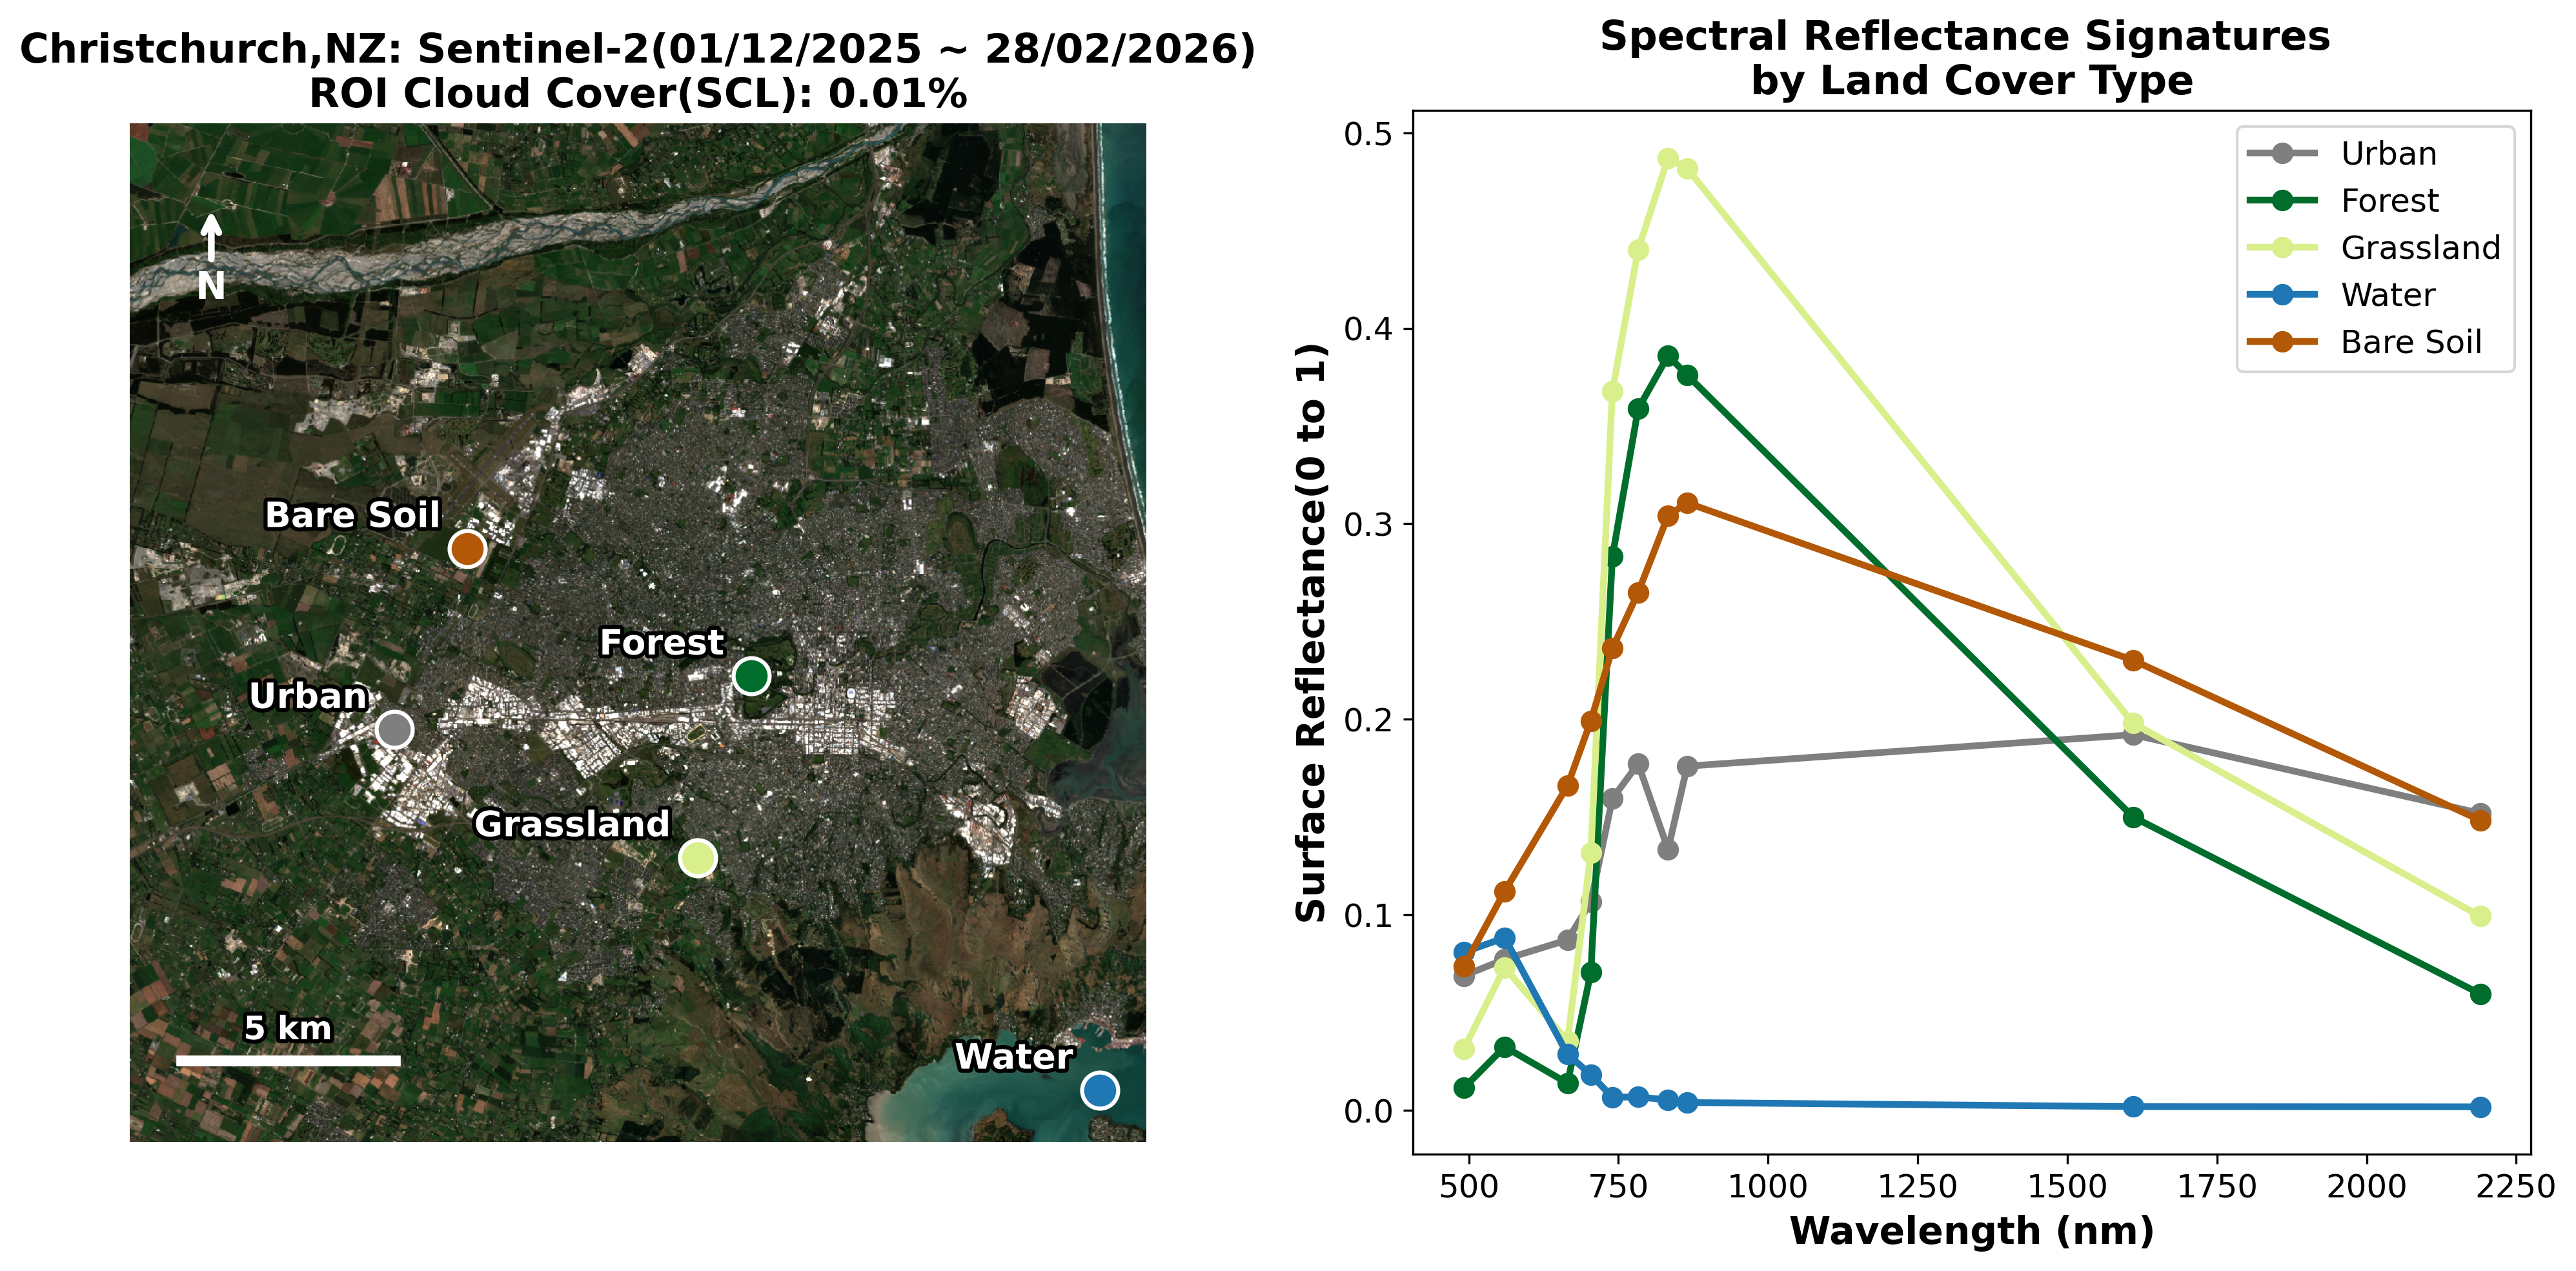

In [47]:
fig = plt.figure(figsize=(16, 7), dpi=300)
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.1], wspace=0.25)

#First Panel: Map with sample points
axA = fig.add_subplot(gs[0])
axA.imshow(thumb_img)
axA.axis('off')

for name, geom in sample_sites.items():
    centroid = geom.centroid().coordinates().getInfo()
    x, y = lonlat_to_px(centroid[0], centroid[1])
    axA.scatter(x, y, s=180, color=class_colors[name],
                edgecolor='white', linewidth=1.5, zorder=5)

    # Place labels on the LEFT side of points
    axA.annotate(name, (x, y), textcoords="offset points",
                 xytext=(-10, 8), ha='right', fontsize=13, color='white',
                 weight='bold',
                 path_effects=[__import__('matplotlib.patheffects', fromlist=['withStroke']).withStroke(linewidth=3, foreground='black')])

axA.set_title(f"Christchurch,NZ: Sentinel-2(01/12/2025 ~ 28/02/2026)\nROI Cloud Cover(SCL): {cloud_coverage_pct_scl:.2f}%",
              fontsize=15, weight='bold')

#  North Arrow
axA.annotate('N', xy=(0.08, 0.92), xytext=(0.08, 0.82),
             xycoords='axes fraction', textcoords='axes fraction',
             ha='center', va='bottom', fontsize=14, fontweight='bold', color='white',
             arrowprops=dict(arrowstyle='->', lw=2.5, color='white'))

#Scale Bar
total_dist_km = (max_lon - min_lon) * 111 * np.cos(np.radians((min_lat + max_lat)/2))
scale_km = 5.0  # 5 km scale bar
bar_len_px = (scale_km / total_dist_km) * img_w

bar_x = img_w * 0.05
bar_y = img_h * 0.92
axA.plot([bar_x, bar_x + bar_len_px], [bar_y, bar_y], color='white', lw=4)
axA.text(bar_x + (bar_len_px / 2), bar_y - 15, f'{int(scale_km)} km',
         color='white', fontsize=12, fontweight='bold', ha='center', va='bottom',
         path_effects=[__import__('matplotlib.patheffects', fromlist=['withStroke']).withStroke(linewidth=3, foreground='black')])

# Second Panel: Spectral signatures
axB = fig.add_subplot(gs[1])
for name, vals in spectra.items():
    axB.plot(wavelengths, vals, marker='o', linewidth=2.5,
             markersize=7, color=class_colors[name], label=name)

axB.set_xlabel('Wavelength (nm)', fontsize=14, weight='bold')
axB.set_ylabel('Surface Reflectance(0 to 1)', fontsize=14, weight='bold')
axB.set_title('Spectral Reflectance Signatures \nby Land Cover Type', fontsize=15, weight='bold')
axB.tick_params(axis='both', labelsize=12)
axB.legend(fontsize=12, frameon=True, loc='upper right')
# axB.grid(alpha=0.3, linestyle='--')
axB.grid(False)#according to nature guidelines, this is a no-no

plt.tight_layout()
plt.savefig('christchurch_s2_figure.png', dpi=300, bbox_inches='tight')
plt.show()